# Theta phase entrainment of hippocampal CA1 neurons

Hippocampal spiking during locomotion and REM sleep is organised by the theta
rhythm, a 6-10 Hz oscillation in the local field potential. Individual neurons
do not fire uniformly across the theta cycle: each cell has a preferred phase
at which its spikes cluster. This notebook demonstrates that entrainment
directly from data in the DANDI Archive, quantifies it per neuron, and shows
that it is specific to the theta band and to the brain states in which theta
is actually present.

**Dataset.** [DANDI 000044](https://dandiarchive.org/dandiset/000044), Grosmark
and Buzsáki (2016), *Diversity in neural firing dynamics supports both rigid
and learned hippocampal sequences* (Science 351:1440). Bilateral silicon-probe
recordings from dorsal CA1 of freely moving rats. Each session contains a
pre-task sleep block, a run on a 1.6 m linear track, and a post-task sleep
block. Every NWB file provides a 1250 Hz LFP `ElectricalSeries` on 128-256
channels, spike-sorted units labelled `excitatory` or `inhibitory`, position
tracking, and scored sleep states (Awake / Non-REM / REM).

**Approach.**

1. Stream the NWB files from the archive with `remfile` and a disk cache; no
   file is downloaded in full (they are 5-9 GB each).
2. Pick the LFP channel with the largest theta/delta power ratio during running.
3. Band-pass filter 6-10 Hz and take the Hilbert phase.
4. Read the theta phase at every spike of every unit with Pynapple.
5. Quantify locking with the mean resultant length (MRL) and test it against a
   circular-shift null that preserves spike count and burst structure.
6. Repeat in REM sleep (theta present) and non-REM sleep (theta absent), and
   across frequency bands, to show that the locking is specific to theta.

Everything runs on four sessions from three animals.

## Setup

In [1]:
%matplotlib inline
import json
import os
import pickle
import urllib.request

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import remfile
from matplotlib.gridspec import GridSpec
from scipy.signal import hilbert, welch
from scipy.stats import mannwhitneyu, wilcoxon
from tqdm.auto import tqdm

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "axes.titlesize": 11, "font.size": 10})

DANDISET = "000044"
CACHE_DIR = "/tmp/remfile_cache_000044"     # streamed byte ranges land here
LFP_RATE = 1250.0                            # Hz
THETA_BAND = (6.0, 10.0)
DELTA_BAND = (1.0, 4.0)
RUN_SPEED = 0.10                             # m/s
MIN_SPIKES = 100                             # per unit and state, to be analysed
N_SHUFFLE = 200
SPECTRUM_BANDS = [(c - 1.5, c + 1.5) for c in
                  [3, 5, 7, 8, 9, 11, 14, 18, 22, 27, 33, 40]]
SPECTRUM_SECONDS = 1200                      # duration-match states before comparing

SESSIONS = [
    "sub-Achilles/sub-Achilles_ses-Achilles-10252013_behavior+ecephys.nwb",
    "sub-Achilles/sub-Achilles_ses-Achilles-11012013_behavior+ecephys.nwb",
    "sub-Cicero/sub-Cicero_ses-Cicero-09012014_behavior+ecephys.nwb",
    "sub-Gatsby/sub-Gatsby_ses-Gatsby-08022013_behavior+ecephys.nwb",
]

CT_COLOR = {"excitatory": "C0", "inhibitory": "C1"}
STATE_COLOR = {"run": "C2", "REM": "C4", "nonREM": "0.5"}
NBINS = 36
BINS = np.linspace(0, 2 * np.pi, NBINS + 1)
CENTERS = (BINS[:-1] + BINS[1:]) / 2
TWO_C = np.concatenate([CENTERS, CENTERS + 2 * np.pi])

## Streaming access to the NWB files

The LFP dataset is chunked one channel at a time (`chunks=(170221, 1)`), so a
single-channel read touches only the bytes for that channel. That is what makes
a phase analysis on a 9 GB file practical over the network.

In [2]:
def asset_urls():
    """Map asset path -> download URL for every asset in the dandiset."""
    url = (f"https://api.dandiarchive.org/api/dandisets/{DANDISET}"
           "/versions/draft/assets/?page_size=100")
    meta = json.load(urllib.request.urlopen(url))
    return {r["path"]: (f"https://api.dandiarchive.org/api/dandisets/{DANDISET}"
                        f"/versions/draft/assets/{r['asset_id']}/download/")
            for r in meta["results"]}


URLS = asset_urls()


def open_session(path):
    rem = remfile.File(URLS[path], disk_cache=remfile.DiskCache(CACHE_DIR))
    return h5py.File(rem, "r")


def _decode(arr):
    return np.array([x.decode() if isinstance(x, bytes) else x for x in arr])


def load_spikes(h5):
    """Units as a pynapple TsGroup carrying cell_type / location / shank metadata."""
    st = h5["units/spike_times"]
    idx = h5["units/spike_times_index"][:]
    starts = np.concatenate([[0], idx[:-1]])
    spikes = {i: nap.Ts(t=st[a:b]) for i, (a, b) in enumerate(zip(starts, idx))}
    meta = dict(cell_type=_decode(h5["units/cell_type"][:]),
                location=_decode(h5["units/location"][:]),
                shank_id=h5["units/shank_id"][:])
    return nap.TsGroup(spikes, **meta)


def load_epochs(h5):
    ep = h5["intervals/epochs"]
    return {lab: nap.IntervalSet(start=s, end=e)
            for lab, s, e in zip(_decode(ep["label"][:]),
                                 ep["start_time"][:], ep["stop_time"][:])}


def load_states(h5):
    st = h5["processing/behavior/states"]
    labels = _decode(st["label"][:])
    starts, stops = st["start_time"][:], st["stop_time"][:]
    return {lab: nap.IntervalSet(start=starts[labels == lab],
                                 end=stops[labels == lab])
            for lab in np.unique(labels)}


def _spatial_series(h5, suffix):
    beh = h5["processing/behavior"]
    grp = beh[[k for k in beh if k.endswith(suffix)][0]]
    ss = grp[list(grp.keys())[0]]
    data = ss["data"][:]
    t0 = ss["starting_time"][()]
    rate = ss["starting_time"].attrs["rate"]
    return t0 + np.arange(data.shape[0]) / rate, np.atleast_2d(data.T).T


def load_position(h5):
    """(2-D position, linearised position, speed).

    The linearised coordinate is defined only while the animal traverses the
    track, so speed is computed from the raw (x, y) tracking. Samples where
    tracking dropped out are discarded rather than interpolated.
    """
    t, lin_xy = _spatial_series(h5, "LinearizedPosition")
    ok = ~np.isnan(lin_xy[:, 0])
    lin = nap.Tsd(t=t[ok], d=lin_xy[ok, 0])

    t2, xy = _spatial_series(h5, "MazePosition")
    good = ~np.isnan(xy).any(axis=1)
    t2, xy = t2[good], xy[good]
    pos = nap.TsdFrame(t=t2, d=xy, columns=["x", "y"])

    dt = np.median(np.diff(t2))
    v = np.hypot(np.gradient(xy[:, 0], t2), np.gradient(xy[:, 1], t2))
    win = max(1, int(round(0.25 / dt)))      # 250 ms boxcar
    v = np.convolve(v, np.ones(win) / win, mode="same")
    return pos, lin, nap.Tsd(t=t2, d=v)


def load_lfp_channel(h5, channel, ep=None):
    """Stream one LFP channel (int16 -> volts) as a pynapple Tsd."""
    es = h5["processing/ecephys/LFP/LFP"]
    dset = es["data"]
    conv = dset.attrs.get("conversion", 1.0)
    t0 = es["starting_time"][()]
    n = dset.shape[0]
    if ep is None:
        i0, i1 = 0, n
    else:
        i0 = max(0, int((ep.start[0] - t0) * LFP_RATE))
        i1 = min(n, int(np.ceil((ep.end[-1] - t0) * LFP_RATE)) + 1)
    lfp = nap.Tsd(t=t0 + np.arange(i0, i1) / LFP_RATE,
                  d=dset[i0:i1, channel].astype(np.float64) * conv)
    return lfp.restrict(ep) if ep is not None else lfp


def load_lfp_block(h5, ep, channels):
    """Stream a short multi-channel LFP block (used for channel selection)."""
    es = h5["processing/ecephys/LFP/LFP"]
    dset = es["data"]
    conv = dset.attrs.get("conversion", 1.0)
    t0 = es["starting_time"][()]
    i0 = max(0, int((ep.start[0] - t0) * LFP_RATE))
    i1 = min(dset.shape[0], int((ep.end[-1] - t0) * LFP_RATE))
    data = np.stack([dset[i0:i1, c].astype(np.float64) * conv for c in channels],
                    axis=1)
    return nap.TsdFrame(t=t0 + np.arange(i0, i1) / LFP_RATE, d=data,
                        columns=np.asarray(channels))

## Inspecting one session

`Achilles-10252013` is the prototyping session. Before any analysis, look at
the streams that go into it.

In [3]:
SESSION = SESSIONS[0]
h5 = open_session(SESSION)
spikes = load_spikes(h5)
epochs = load_epochs(h5)
states = load_states(h5)
pos, lin, speed = load_position(h5)
maze = epochs["MazeEpoch"]

print("epochs:", {k: (round(float(v.start[0])), round(float(v.end[-1])))
                  for k, v in epochs.items()})
print("sleep states (s):", {k: round(float(v.tot_length()))
                            for k, v in states.items()})
print(f"{len(spikes)} units: "
      f"{dict(zip(*np.unique(spikes.cell_type, return_counts=True)))}, "
      f"regions {dict(zip(*np.unique(spikes.location, return_counts=True)))}")
print("speed percentiles (m/s):",
      np.round(np.percentile(speed.values, [50, 90, 99]), 2))

epochs: {np.str_('PREEpoch'): (0, 18080), np.str_('MazeEpoch'): (18080, 20147), np.str_('POSTEpoch'): (20147, 34861)}
sleep states (s): {np.str_('Awake'): 16747, np.str_('Non-REM'): 15890, np.str_('REM'): 2071}
137 units: {np.str_('excitatory'): np.int64(120), np.str_('inhibitory'): np.int64(17)}, regions {np.str_('lCA1'): np.int64(65), np.str_('rCA1'): np.int64(72)}
speed percentiles (m/s): [0.13 0.53 0.94]


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


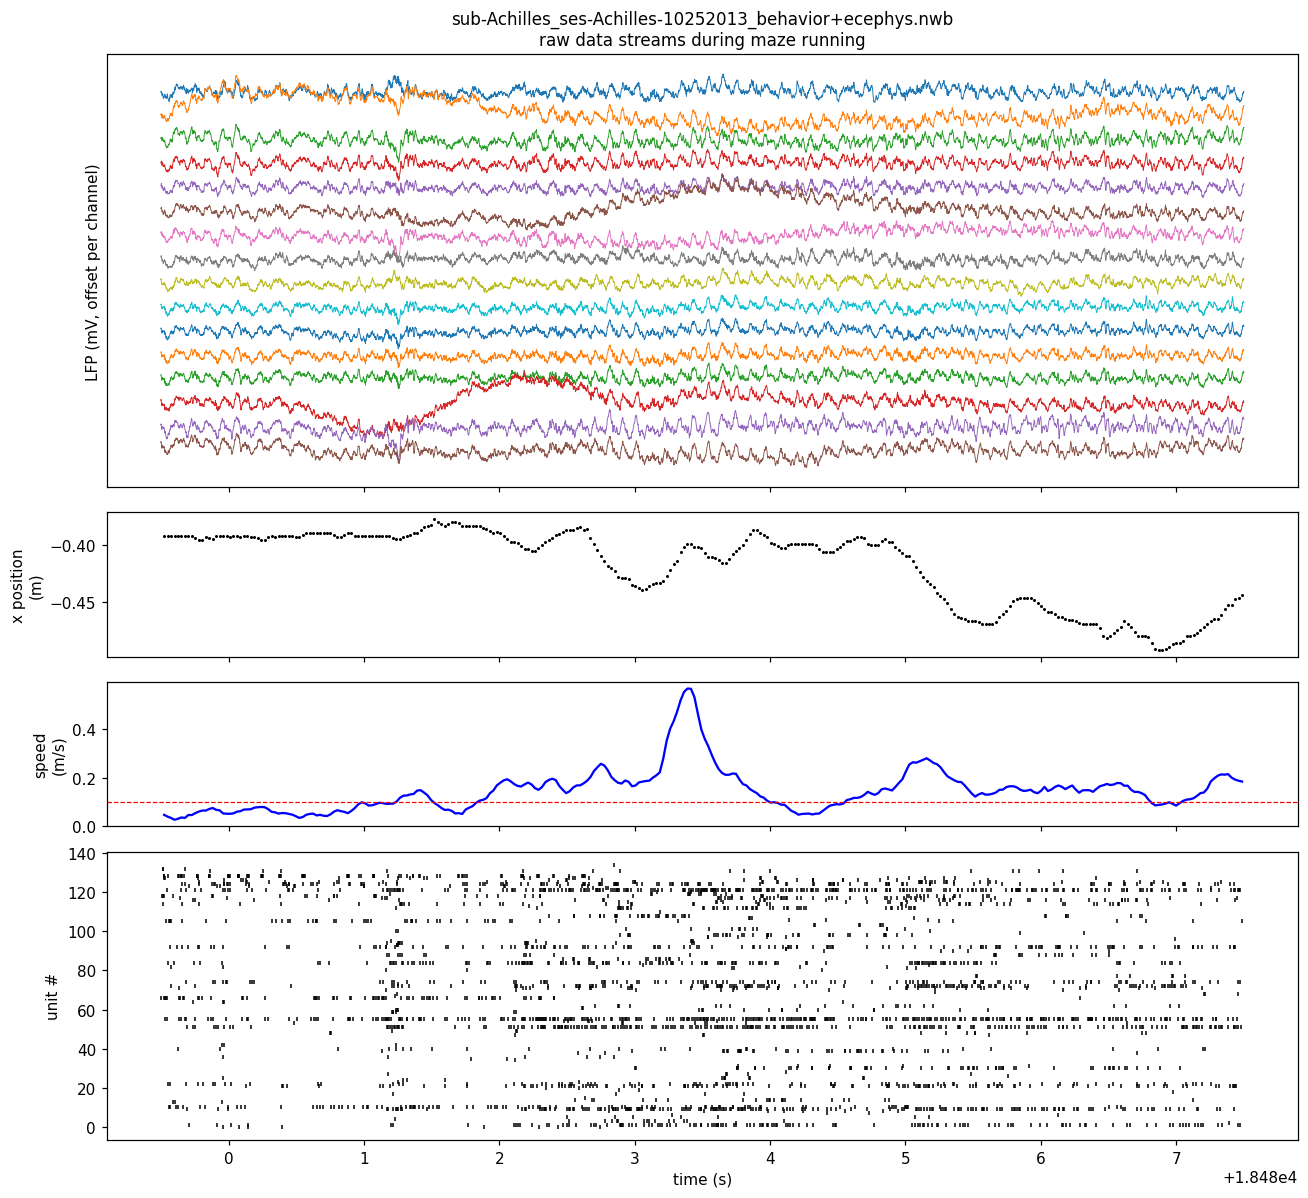

In [4]:
t_mid = float(maze.start[0] + 400)
win = nap.IntervalSet(start=t_mid, end=t_mid + 8)
block = load_lfp_block(h5, win, channels=np.arange(0, 128, 8))

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1, 2]})
for i in range(block.shape[1]):
    axes[0].plot(block.t, block[:, i].values * 1e3 - i * 1.2, lw=0.6)
axes[0].set_ylabel("LFP (mV, offset per channel)")
axes[0].set_yticks([])
axes[0].set_title(f"{SESSION.split('/')[-1]}\nraw data streams during maze running")
axes[1].plot(pos.restrict(win).t, pos.restrict(win)["x"].values, "k.", ms=2)
axes[1].set_ylabel("x position\n(m)")
axes[2].plot(speed.restrict(win).t, speed.restrict(win).values, "b")
axes[2].axhline(RUN_SPEED, color="r", ls="--", lw=0.8)
axes[2].set_ylabel("speed\n(m/s)")
for j, u in enumerate(spikes.keys()):
    ts = spikes[u].restrict(win).t
    axes[3].plot(ts, np.full_like(ts, j), "|", ms=3, color="k")
axes[3].set_ylabel("unit #")
axes[3].set_xlabel("time (s)")
plt.tight_layout()
plt.savefig("fig01_raw_streams.png")

The theta rhythm is already visible by eye in the LFP traces during running.

## Theta extraction

Running is defined as speed above 10 cm/s for at least 0.5 s (short gaps
bridged). The theta channel is the one with the largest 6-10 Hz over 1-4 Hz
power ratio during running, computed from a 120 s probe window read across all
channels.

In [5]:
def run_epochs(speed, maze, thresh=RUN_SPEED, min_dur=0.5):
    ep = speed.restrict(maze).threshold(thresh, "above").time_support
    ep = ep.merge_close_intervals(0.25)
    return ep[(ep.end - ep.start) >= min_dur]


def theta_delta_ratio(sig, fs=LFP_RATE):
    f, p = welch(sig, fs=fs, nperseg=int(4 * fs))
    th = p[(f >= THETA_BAND[0]) & (f <= THETA_BAND[1])].mean()
    de = p[(f >= DELTA_BAND[0]) & (f <= DELTA_BAND[1])].mean()
    return th / de


def select_theta_channel(h5, run_ep, probe_seconds=120):
    n_ch = h5["processing/ecephys/LFP/LFP/data"].shape[1]
    probe = nap.IntervalSet(start=float(run_ep.start[0]),
                            end=float(run_ep.start[0]) + probe_seconds)
    block = load_lfp_block(h5, probe, channels=np.arange(n_ch)).restrict(run_ep)
    ratios = np.array([theta_delta_ratio(block[:, i].values) for i in range(n_ch)])
    return int(np.argmax(ratios)), ratios


def theta_phase(lfp, band=THETA_BAND, fs=LFP_RATE):
    """Band-pass filter and return (filtered, phase, amplitude) as Tsd.

    Phase is on [0, 2π) with 0 at the peak of the filtered cycle and π at the
    trough. Pynapple filters each interval of the time support separately, and
    the Hilbert transform is applied within the same boundaries so that phase
    never wraps across a gap.
    """
    filt = nap.apply_bandpass_filter(lfp, band, fs=fs)
    phase = np.empty(len(filt))
    amp = np.empty(len(filt))
    for ep in filt.time_support:
        slc = filt.get_slice(start=ep.start[0], end=ep.end[0])
        analytic = hilbert(filt.values[slc])
        phase[slc] = np.mod(np.angle(analytic), 2 * np.pi)
        amp[slc] = np.abs(analytic)
    ts = filt.time_support
    return (filt, nap.Tsd(t=filt.t, d=phase, time_support=ts),
            nap.Tsd(t=filt.t, d=amp, time_support=ts))

In [6]:
run_ep = run_epochs(speed, maze)
print(f"running: {len(run_ep)} bouts, {float(run_ep.tot_length()):.0f} s of "
      f"{float(maze.tot_length()):.0f} s on the maze")

best_ch, ratios = select_theta_channel(h5, run_ep)
print(f"theta channel {best_ch}: theta/delta = {ratios[best_ch]:.2f} "
      f"(median across channels {np.median(ratios):.2f})")

lfp_full = load_lfp_channel(h5, best_ch)     # one channel, whole session
print(f"streamed {len(lfp_full)} LFP samples "
      f"({len(lfp_full) / LFP_RATE / 3600:.1f} h)")

running: 279 bouts, 1363 s of 2068 s on the maze


theta channel 34: theta/delta = 4.22 (median across channels 2.13)


streamed 43576379 LFP samples (9.7 h)


## Brain states

Three states are compared. Running on the maze and REM sleep both have theta;
non-REM sleep does not, and serves as the control state. REM and non-REM are
taken from the sleep blocks that flank the task so they never overlap running.

In [7]:
sleep = epochs["PREEpoch"].union(epochs["POSTEpoch"])
state_eps = {"run": run_ep,
             "REM": states["REM"].intersect(sleep),
             "nonREM": states["Non-REM"].intersect(sleep)}
for k, v in state_eps.items():
    print(f"{k}: {len(v)} intervals, {float(v.tot_length()):.0f} s")

psds = {k: welch(lfp_full.restrict(v).values, fs=LFP_RATE,
                 nperseg=int(4 * LFP_RATE))
        for k, v in state_eps.items()}

run: 279 intervals, 1363 s
REM: 22 intervals, 2071 s
nonREM: 60 intervals, 15890 s


peak frequency during running: 9.25 Hz


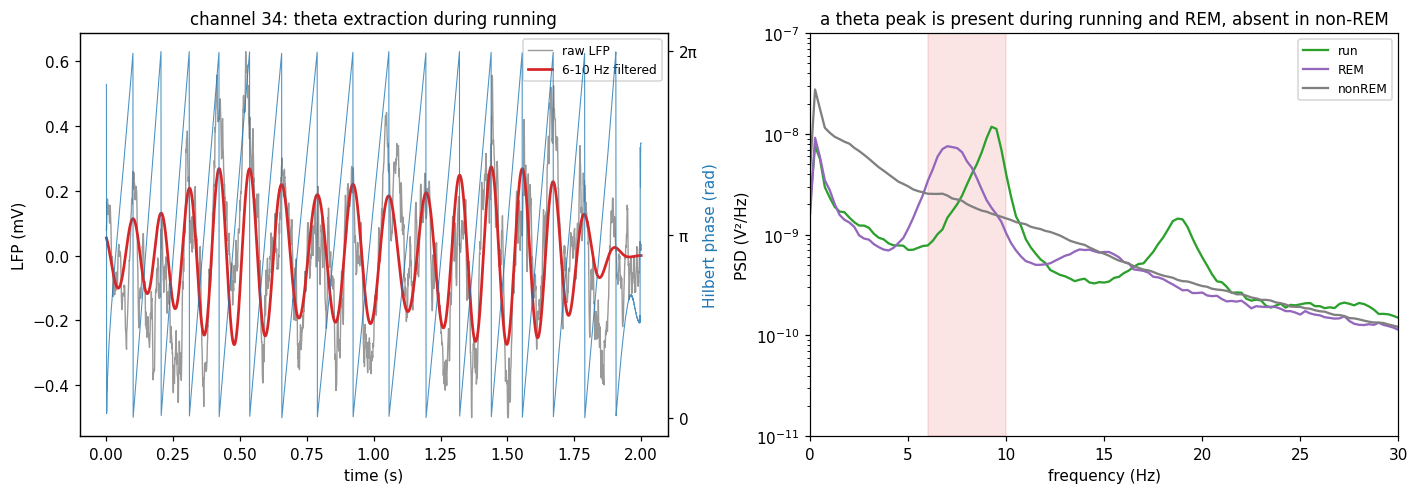

In [8]:
lfp_run = lfp_full.restrict(run_ep)
filt_run, phase_run, amp_run = theta_phase(lfp_run)

# a 2 s excerpt for display
t0 = float(run_ep.start[len(run_ep) // 2])
ex_ep = nap.IntervalSet(start=t0, end=t0 + 2)
ex_lfp = lfp_full.restrict(ex_ep)
ex_filt, ex_phase, _ = theta_phase(ex_lfp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(ex_lfp.t - t0, ex_lfp.values * 1e3, color="0.6", lw=0.9, label="raw LFP")
ax.plot(ex_filt.t - t0, ex_filt.values * 1e3, color="C3", lw=1.8,
        label="6-10 Hz filtered")
axp = ax.twinx()
axp.plot(ex_phase.t - t0, ex_phase.values, color="C0", lw=0.7, alpha=0.8)
axp.set_ylabel("Hilbert phase (rad)", color="C0")
axp.set_yticks([0, np.pi, 2 * np.pi])
axp.set_yticklabels(["0", "π", "2π"])
ax.set_xlabel("time (s)")
ax.set_ylabel("LFP (mV)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(f"channel {best_ch}: theta extraction during running")

ax = axes[1]
for state, (f, p) in psds.items():
    ax.semilogy(f, p, color=STATE_COLOR[state], label=state)
ax.axvspan(*THETA_BAND, color="C3", alpha=0.12)
ax.set_xlim(0, 30)
ax.set_ylim(1e-11, 1e-7)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (V²/Hz)")
ax.set_title("a theta peak is present during running and REM, absent in non-REM")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig02_theta_signal.png")

f, p = psds["run"]
sel = (f > 4) & (f < 12)
print(f"peak frequency during running: {f[sel][np.argmax(p[sel])]:.2f} Hz")

## Spike phases and circular statistics

For every unit, `value_from` returns the theta phase sample nearest each spike.
Locking is summarised by the mean resultant length (MRL) of those phases, with
the preferred phase as the direction of the mean vector.

The Rayleigh test is reported but is anti-conservative for spike trains,
because spikes within a burst are not independent samples. The test used
throughout is a circular-shift null: the theta phase series is rotated by a
random offset relative to the spike train, which preserves spike count, the
burst structure of the train, and the marginal distribution of phase, while
destroying the relationship between them.

In [9]:
def circular_stats(phases):
    n = len(phases)
    if n == 0:
        return dict(n=0, mrl=np.nan, pref=np.nan, p=np.nan)
    r = np.exp(1j * phases).mean()
    mrl, pref = np.abs(r), np.mod(np.angle(r), 2 * np.pi)
    # Zar (1999) approximation to the Rayleigh p-value
    p = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - (n * mrl) ** 2)) - (1 + 2 * n))
    return dict(n=n, mrl=mrl, pref=pref, p=p)


def spike_phases(unit_ts, phase_tsd, ep):
    """Theta phase at each spike. Nearest sample, not interpolation: linear
    interpolation would be wrong across the 2π wrap. At 1250 Hz the residual
    error is below 0.03 rad for an 8 Hz oscillation."""
    ts = unit_ts.restrict(ep)
    if len(ts) == 0:
        return np.array([])
    ph = ts.value_from(phase_tsd).values
    return ph[~np.isnan(ph)]


class PhaseLookup:
    """Concatenated phase series supporting fast circular-shift shuffles."""

    def __init__(self, phase_tsd, ep):
        self.ep = ep
        self.phase_t = phase_tsd.t
        self.phase_v = np.exp(1j * phase_tsd.values)
        self.m = len(self.phase_t)

    def null_mrl(self, unit_ts, n_shuffle=N_SHUFFLE, rng=None):
        rng = rng or np.random.default_rng(0)
        ts = unit_ts.restrict(self.ep).t
        if len(ts) == 0:
            return np.full(n_shuffle, np.nan)
        idx = np.clip(np.searchsorted(self.phase_t, ts), 0, self.m - 1)
        return np.array([np.abs(self.phase_v[(idx + k) % self.m].mean())
                         for k in rng.integers(0, self.m, size=n_shuffle)])


def cap_duration(ep, seconds):
    """Whole intervals from the start of `ep` totalling at most `seconds`."""
    cum = np.cumsum(ep.end - ep.start)
    return ep[:min(int(np.searchsorted(cum, seconds)) + 1, len(ep))]

## The full per-session pipeline

For each session and each of the three states this computes spike phases,
circular statistics and the shuffle test for every unit; the locking spectrum
across frequency bands on a duration-matched slice; a split of the running data
by theta amplitude; and a spike-count-matched MRL so the states can be compared
without the upward bias that MRL carries at small spike counts. Results are
cached to disk, so re-running the notebook is cheap.

In [10]:
def session_tag(path):
    return path.split("/")[-1].replace("_behavior+ecephys.nwb", "").replace("sub-", "")


def compute_session(path, use_cache=True, verbose=True):
    tag = session_tag(path)
    cache = f"nb_cache_{tag}.pkl"
    if use_cache and os.path.exists(cache):
        with open(cache, "rb") as fh:
            return pickle.load(fh)

    h5 = open_session(path)
    spikes = load_spikes(h5)
    epochs = load_epochs(h5)
    states = load_states(h5)
    _, _, speed = load_position(h5)
    maze = epochs["MazeEpoch"]
    run_ep = run_epochs(speed, maze)
    sleep = epochs["PREEpoch"].union(epochs["POSTEpoch"])
    state_eps = {"run": run_ep,
                 "REM": states["REM"].intersect(sleep),
                 "nonREM": states["Non-REM"].intersect(sleep)}

    best_ch, ratios = select_theta_channel(h5, run_ep)
    if verbose:
        print(f"[{tag}] theta channel {best_ch}, "
              f"theta/delta={ratios[best_ch]:.2f}; "
              + ", ".join(f"{k}={float(v.tot_length()):.0f}s"
                          for k, v in state_eps.items()))
    lfp_full = load_lfp_channel(h5, best_ch)

    rows, phases, spectra, psds, amp_split = [], {}, {}, {}, []
    for state, ep in state_eps.items():
        if float(ep.tot_length()) < 60:
            continue
        lfp = lfp_full.restrict(ep)
        psds[state] = welch(lfp.values, fs=LFP_RATE, nperseg=int(4 * LFP_RATE))
        _, phase, amp = theta_phase(lfp)
        lookup = PhaseLookup(phase, ep)
        for u in tqdm(spikes.keys(), desc=f"[{tag}] {state}", disable=not verbose):
            ph = spike_phases(spikes[u], phase, ep)
            st = circular_stats(ph)
            phases[(state, int(u))] = ph.astype(np.float32)
            row = dict(session=tag, unit=int(u),
                       cell_type=str(spikes.cell_type[u]),
                       location=str(spikes.location[u]), state=state,
                       n_spikes=st["n"], rate=st["n"] / float(ep.tot_length()),
                       mrl=st["mrl"], pref_phase=st["pref"],
                       rayleigh_p=st["p"], theta_channel=best_ch)
            if st["n"] >= MIN_SPIKES:
                null = lookup.null_mrl(spikes[u],
                                       rng=np.random.default_rng(1000 + int(u)))
                row.update(null_mrl_mean=float(np.nanmean(null)),
                           null_mrl_p95=float(np.nanpercentile(null, 95)),
                           shuffle_p=(np.sum(null >= st["mrl"]) + 1)
                                     / (N_SHUFFLE + 1))
            else:
                row.update(null_mrl_mean=np.nan, null_mrl_p95=np.nan,
                           shuffle_p=np.nan)
            rows.append(row)

        if state == "run":
            thr = np.median(amp.values)
            hi = amp.threshold(thr, "above").time_support
            lo = amp.threshold(thr, "below").time_support
            for u in spikes.keys():
                r = dict(session=tag, unit=int(u),
                         cell_type=str(spikes.cell_type[u]))
                for lbl, sub in [("high", hi), ("low", lo)]:
                    s = circular_stats(spike_phases(spikes[u], phase,
                                                    ep.intersect(sub)))
                    r[f"mrl_{lbl}"], r[f"n_{lbl}"] = s["mrl"], s["n"]
                amp_split.append(r)

        ep_s = cap_duration(ep, SPECTRUM_SECONDS)
        lfp_s = lfp_full.restrict(ep_s)
        for band in tqdm(SPECTRUM_BANDS, desc=f"[{tag}] {state} spectrum",
                         disable=not verbose):
            _, ph_b, _ = theta_phase(lfp_s, band=band)
            for u in spikes.keys():
                s = circular_stats(spike_phases(spikes[u], ph_b, ep_s))
                spectra.setdefault((state, int(u)), []).append(s["mrl"])

    df = pd.DataFrame(rows)

    # Spike-count-matched MRL: every unit contributes the same number of spikes
    # in every state, removing the small-n bias of the MRL.
    matched, rng = [], np.random.default_rng(0)
    for u in {k[1] for k in phases}:
        avail = {s: phases[(s, u)] for s in state_eps if (s, u) in phases}
        n = min(len(v) for v in avail.values())
        for s, v in avail.items():
            sel = rng.choice(v, size=n, replace=False) if len(v) > n else v
            st = circular_stats(sel)
            matched.append(dict(unit=u, state=s, n_matched=n,
                                mrl_matched=st["mrl"], pref_matched=st["pref"]))
    df = df.merge(pd.DataFrame(matched), on=["unit", "state"], how="left")

    # Raw excerpt: the running bout with the highest population firing rate.
    durations = run_ep.end - run_ep.start
    counts = np.array([sum(len(spikes[u].restrict(run_ep[i:i + 1]))
                           for u in spikes.keys()) for i in range(len(run_ep))])
    best = int(np.argmax(np.where(durations > 3, counts / durations, 0)))
    t0 = float(run_ep.start[best])
    ex = nap.IntervalSet(start=t0, end=min(t0 + 3.5, float(run_ep.end[best])))
    lfp_ex = lfp_full.restrict(ex)
    filt_ex, phase_ex, _ = theta_phase(lfp_ex)

    out = dict(tag=tag, df=df, phases=phases, psds=psds,
               spectrum=pd.DataFrame(spectra,
                                     index=[np.mean(b) for b in SPECTRUM_BANDS]),
               amp_split=pd.DataFrame(amp_split), best_ch=best_ch,
               cell_type={int(u): str(spikes.cell_type[u]) for u in spikes.keys()},
               state_durations={k: float(v.tot_length())
                                for k, v in state_eps.items()},
               excerpt=dict(t=lfp_ex.t, raw=lfp_ex.values, filt=filt_ex.values,
                            phase=phase_ex.values,
                            spikes={int(u): spikes[u].restrict(ex).t
                                    for u in spikes.keys()}))
    with open(cache, "wb") as fh:
        pickle.dump(out, fh)
    return out

In [11]:
results = [compute_session(s) for s in SESSIONS]
df = pd.concat([r["df"] for r in results], ignore_index=True)
df.to_csv("phase_locking_all_sessions.csv", index=False)
prototype = results[0]
print(df.groupby(["state", "cell_type"]).mrl.median().round(3).to_string())

state   cell_type 
REM     excitatory    0.126
        inhibitory    0.264
nonREM  excitatory    0.091
        inhibitory    0.077
run     excitatory    0.104
        inhibitory    0.173


## Entrainment is visible in single theta cycles

Before any statistics: within one running bout, the spikes of the most
strongly locked units fall at a consistent position on each theta cycle, and
different units prefer different positions.

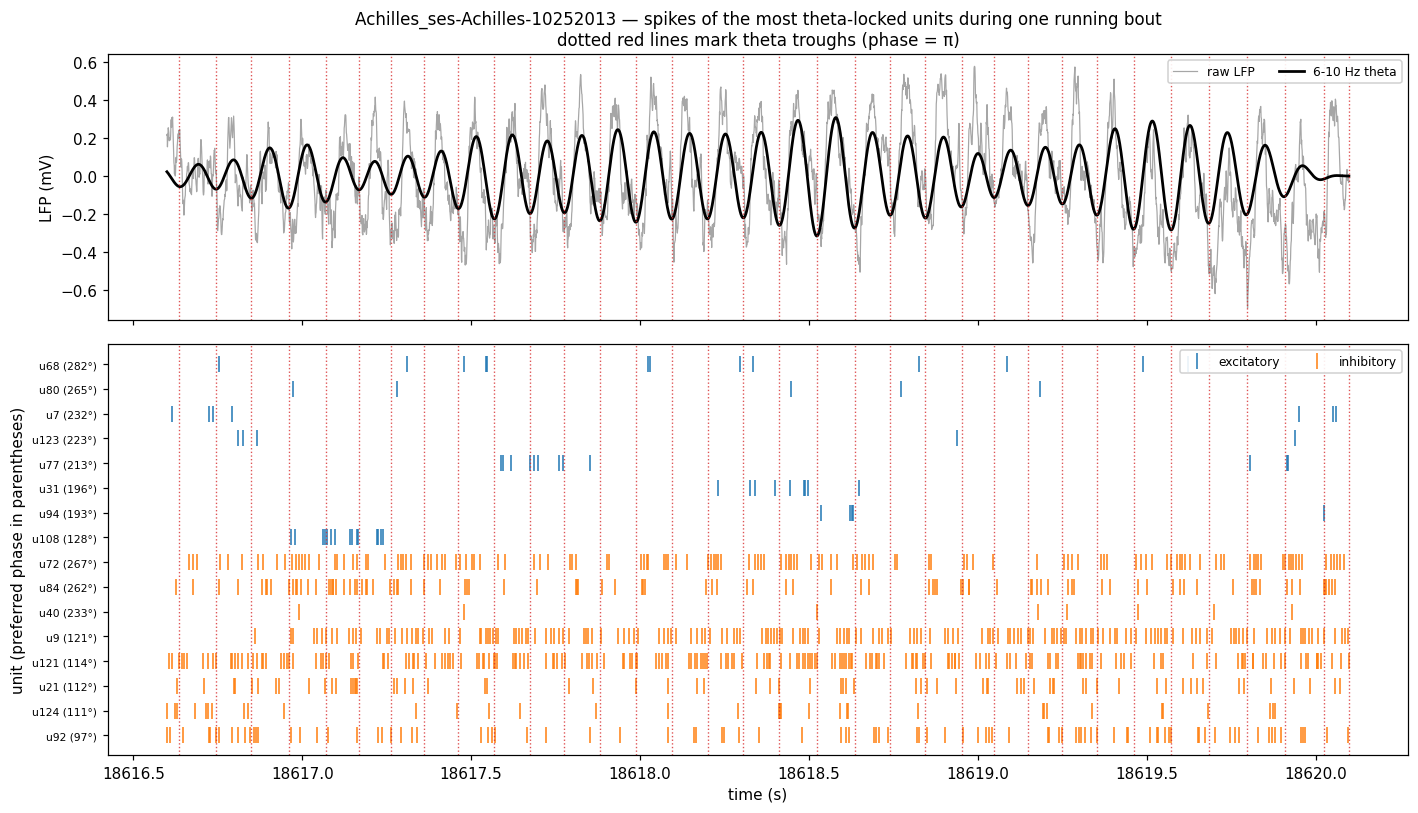

In [12]:
def phase_hist(ph):
    cnt, _ = np.histogram(ph, bins=BINS)
    return cnt / cnt.sum() if cnt.sum() else cnt


def two_cycles(y):
    return np.concatenate([y, y])


ex = prototype["excerpt"]
run_rows = prototype["df"][prototype["df"].state == "run"].copy()
run_rows["n_in_window"] = [len(ex["spikes"][int(u)]) for u in run_rows.unit]
pick = []
for ct in ["inhibitory", "excitatory"]:
    sub = run_rows[(run_rows.cell_type == ct) & (run_rows.n_in_window >= 5)]
    pick.append(sub.sort_values("mrl", ascending=False).head(8)
                .sort_values("pref_phase"))
order_df = pd.concat(pick)
order = list(order_df.unit)
troughs = ex["t"][1:][(ex["phase"][:-1] < np.pi) & (ex["phase"][1:] >= np.pi)]

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                         gridspec_kw={"height_ratios": [1.1, 1.7]})
ax = axes[0]
ax.plot(ex["t"], ex["raw"] * 1e3, color="0.65", lw=0.8, label="raw LFP")
ax.plot(ex["t"], ex["filt"] * 1e3, color="k", lw=1.8, label="6-10 Hz theta")
for tt in troughs:
    ax.axvline(tt, color="C3", lw=0.9, ls=":", alpha=0.8)
ax.set_ylabel("LFP (mV)")
ax.legend(loc="upper right", fontsize=8, ncol=2, framealpha=0.9)
ax.set_title(f"{prototype['tag']} — spikes of the most theta-locked units during "
             "one running bout\ndotted red lines mark theta troughs (phase = π)")
ax = axes[1]
for j, u in enumerate(order):
    t = ex["spikes"][u]
    ax.plot(t, np.full_like(t, j), "|", ms=10,
            color=CT_COLOR[prototype["cell_type"][u]])
for tt in troughs:
    ax.axvline(tt, color="C3", lw=0.9, ls=":", alpha=0.8)
ax.set_ylim(-0.8, len(order) - 0.2)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"u{int(u)} ({np.degrees(p):.0f}°)"
                    for u, p in zip(order_df.unit, order_df.pref_phase)],
                   fontsize=7)
ax.set_ylabel("unit (preferred phase in parentheses)")
ax.set_xlabel("time (s)")
ax.legend(handles=[plt.Line2D([], [], color=c, marker="|", ls="", ms=10, label=k)
                   for k, c in CT_COLOR.items()],
          loc="upper right", fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig03_spike_phase_excerpt.png")

## Single-unit phase histograms and the shuffle test

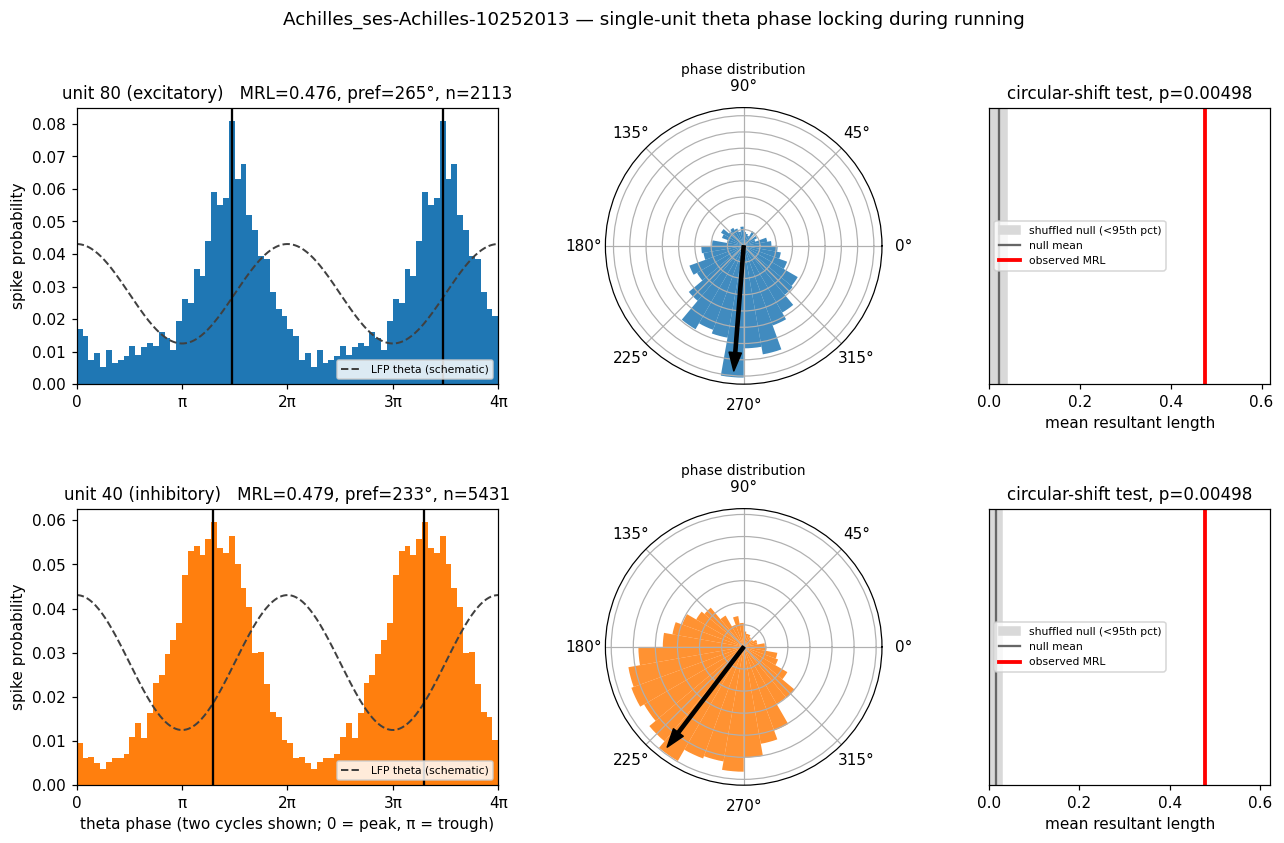

In [13]:
run_all = df[(df.state == "run") & (df.n_spikes >= 500)]
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1.5, 1, 1], hspace=0.45, wspace=0.32)
for r, ct in enumerate(["excitatory", "inhibitory"]):
    row = (run_all[(run_all.cell_type == ct) & (run_all.session == prototype["tag"])]
           .sort_values("mrl", ascending=False).iloc[0])
    u = int(row.unit)
    dens = phase_hist(prototype["phases"][("run", u)])

    ax = fig.add_subplot(gs[r, 0])
    ax.bar(TWO_C, two_cycles(dens), width=BINS[1] - BINS[0], color=CT_COLOR[ct])
    x = np.linspace(0, 4 * np.pi, 400)
    ax.plot(x, dens.mean() * (1 + 0.55 * np.cos(x)), color="0.25", lw=1.3,
            ls="--", label="LFP theta (schematic)")
    ax.axvline(row.pref_phase, color="k", lw=1.5)
    ax.axvline(row.pref_phase + 2 * np.pi, color="k", lw=1.5)
    ax.set_xlim(0, 4 * np.pi)
    ax.set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi])
    ax.set_xticklabels(["0", "π", "2π", "3π", "4π"])
    ax.set_ylabel("spike probability")
    ax.set_title(f"unit {u} ({ct})   MRL={row.mrl:.3f}, "
                 f"pref={np.degrees(row.pref_phase):.0f}°, n={int(row.n_spikes)}")
    ax.legend(fontsize=7, loc="lower right", framealpha=0.85)
    if r == 1:
        ax.set_xlabel("theta phase (two cycles shown; 0 = peak, π = trough)")

    axp = fig.add_subplot(gs[r, 1], projection="polar")
    axp.bar(CENTERS, dens, width=BINS[1] - BINS[0], color=CT_COLOR[ct], alpha=0.85)
    axp.annotate("", xy=(row.pref_phase, row.mrl * dens.max() / 0.5), xytext=(0, 0),
                 arrowprops=dict(color="k", width=2, headwidth=8))
    axp.set_yticklabels([])
    axp.set_title("phase distribution", fontsize=9, pad=22)

    ax2 = fig.add_subplot(gs[r, 2])
    ax2.axvspan(0, row.null_mrl_p95, color="0.85",
                label="shuffled null (<95th pct)")
    ax2.axvline(row.null_mrl_mean, color="0.4", lw=1.5, label="null mean")
    ax2.axvline(row.mrl, color="r", lw=2.5, label="observed MRL")
    ax2.set_xlim(0, max(row.mrl * 1.3, row.null_mrl_p95 * 2))
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])
    ax2.set_xlabel("mean resultant length")
    ax2.set_title(f"circular-shift test, p={row.shuffle_p:.3g}")
    ax2.legend(fontsize=7, loc="center left")
fig.suptitle(f"{prototype['tag']} — single-unit theta phase locking during running",
             y=0.99)
plt.savefig("fig04_example_units.png", bbox_inches="tight")

## The whole population at once

Each row is one unit's firing rate as a function of theta phase, z-scored
across phase and sorted by preferred phase.

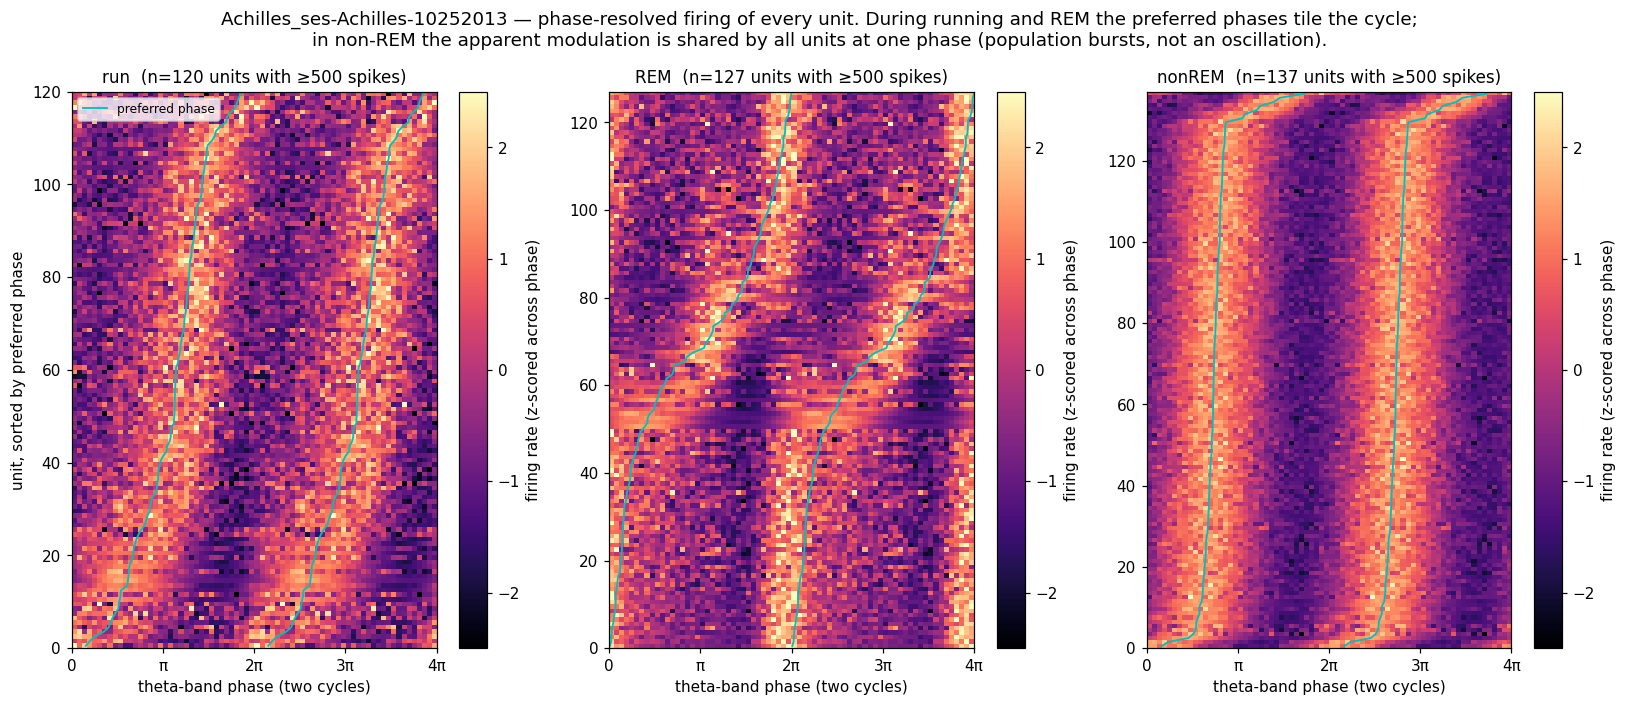

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
for ax, state in zip(axes, ["run", "REM", "nonREM"]):
    sub = prototype["df"]
    sub = sub[(sub.state == state) & (sub.n_spikes >= 500)].sort_values("pref_phase")
    mat = np.array([two_cycles(phase_hist(prototype["phases"][(state, int(u))]))
                    for u in sub.unit])
    mat = (mat - mat.mean(axis=1, keepdims=True)) / mat.std(axis=1, keepdims=True)
    im = ax.imshow(mat, aspect="auto", origin="lower", cmap="magma",
                   extent=[0, 4 * np.pi, 0, len(sub)], vmin=-2.5, vmax=2.5)
    ax.plot(sub.pref_phase, np.arange(len(sub)) + 0.5, color="c", lw=1.2)
    ax.plot(sub.pref_phase + 2 * np.pi, np.arange(len(sub)) + 0.5, color="c",
            lw=1.2, label="preferred phase")
    ax.set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi])
    ax.set_xticklabels(["0", "π", "2π", "3π", "4π"])
    ax.set_xlabel("theta-band phase (two cycles)")
    ax.set_title(f"{state}  (n={len(sub)} units with ≥500 spikes)")
    if ax is axes[0]:
        ax.set_ylabel("unit, sorted by preferred phase")
        ax.legend(fontsize=8, loc="upper left")
    plt.colorbar(im, ax=ax, label="firing rate (z-scored across phase)")
fig.suptitle(f"{prototype['tag']} — phase-resolved firing of every unit. During "
             "running and REM the preferred phases tile the cycle;\nin non-REM "
             "the apparent modulation is shared by all units at one phase "
             "(population bursts, not an oscillation).")
plt.tight_layout()
plt.savefig("fig05_population_map.png")

## Population statistics

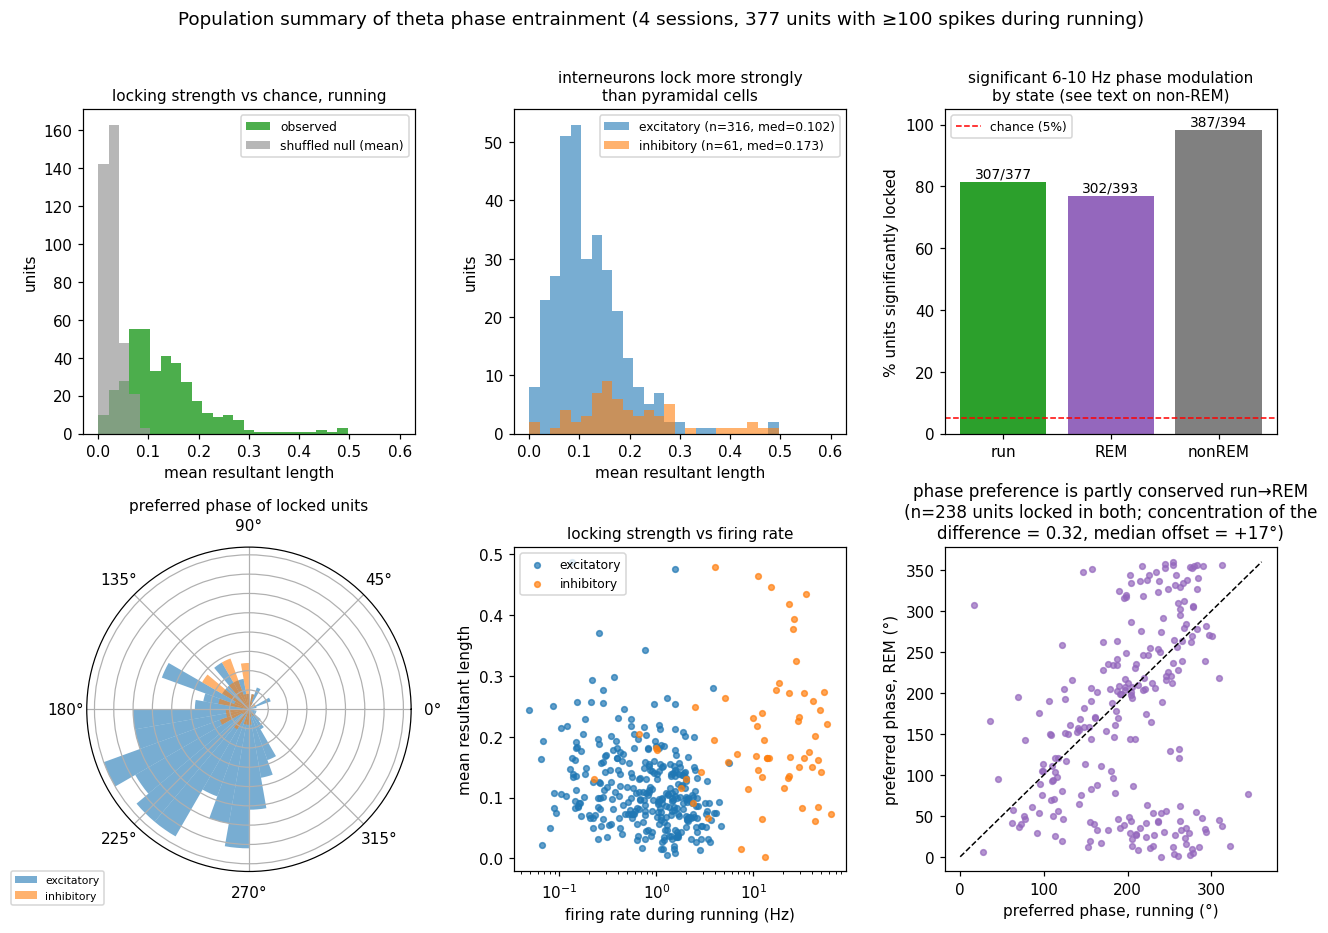

In [15]:
run = df[(df.state == "run") & (df.n_spikes >= MIN_SPIKES)]
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, max(0.6, run.mrl.max() * 1.05), 30)
ax.hist(run.mrl, bins=bins, color="C2", alpha=0.85, label="observed")
ax.hist(run.null_mrl_mean.dropna(), bins=bins, color="0.6", alpha=0.7,
        label="shuffled null (mean)")
ax.set_xlabel("mean resultant length")
ax.set_ylabel("units")
ax.set_title("locking strength vs chance, running", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 1])
for ct, sub in run.groupby("cell_type"):
    ax.hist(sub.mrl, bins=bins, alpha=0.6, color=CT_COLOR[ct],
            label=f"{ct} (n={len(sub)}, med={sub.mrl.median():.3f})")
ax.set_xlabel("mean resultant length")
ax.set_ylabel("units")
ax.set_title("interneurons lock more strongly\nthan pyramidal cells", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 2])
sig = df[df.n_spikes >= MIN_SPIKES]
order = ["run", "REM", "nonREM"]
frac = [100 * (sig[sig.state == s].shuffle_p < 0.05).mean() for s in order]
ax.bar(order, frac, color=[STATE_COLOR[s] for s in order])
for i, s in enumerate(order):
    n = sig[sig.state == s]
    ax.text(i, frac[i] + 1.5, f"{int((n.shuffle_p < 0.05).sum())}/{len(n)}",
            ha="center", fontsize=9)
ax.axhline(5, color="r", ls="--", lw=1, label="chance (5%)")
ax.set_ylabel("% units significantly locked")
ax.set_ylim(0, 105)
ax.set_title("significant 6-10 Hz phase modulation\nby state (see text on non-REM)",
              fontsize=10)
ax.legend(fontsize=8)

axp = fig.add_subplot(gs[1, 0], projection="polar")
for ct, sub in run.groupby("cell_type"):
    cnt, _ = np.histogram(sub[sub.shuffle_p < 0.05].pref_phase, bins=BINS)
    axp.bar(CENTERS, cnt, width=BINS[1] - BINS[0], alpha=0.6, color=CT_COLOR[ct],
            label=ct)
axp.set_yticklabels([])
axp.set_title("preferred phase of locked units", fontsize=10, pad=24)
axp.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.25, -0.12))

ax = fig.add_subplot(gs[1, 1])
for ct, sub in run.groupby("cell_type"):
    ax.scatter(sub.rate, sub.mrl, s=14, alpha=0.7, color=CT_COLOR[ct], label=ct)
ax.set_xscale("log")
ax.set_xlabel("firing rate during running (Hz)")
ax.set_ylabel("mean resultant length")
ax.set_title("locking strength vs firing rate", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 2])
# Units that are not locked have an essentially arbitrary preferred phase, so
# compare run and REM only among units that are locked in both states.
piv = (df[(df.n_spikes >= MIN_SPIKES) & (df.shuffle_p < 0.05)
          & (df.state.isin(["run", "REM"]))]
       .pivot_table(index=["session", "unit"], columns="state",
                    values="pref_phase").dropna(subset=["run", "REM"]))
ax.scatter(np.degrees(piv["run"]), np.degrees(piv["REM"]), s=14, alpha=0.7,
           color="C4")
d = np.angle(np.exp(1j * (piv["REM"] - piv["run"])))
rho = np.abs(np.exp(1j * d).mean())
ax.plot([0, 360], [0, 360], "k--", lw=1)
ax.set_xlabel("preferred phase, running (°)")
ax.set_ylabel("preferred phase, REM (°)")
ax.set_title(f"phase preference is partly conserved run→REM\n(n={len(piv)} units "
             f"locked in both; concentration of the\ndifference = {rho:.2f}, "
             f"median offset = {np.degrees(np.median(d)):+.0f}°)")
fig.suptitle("Population summary of theta phase entrainment "
             f"({df.session.nunique()} sessions, {len(run)} units with "
             f"≥{MIN_SPIKES} spikes during running)", y=0.98)
plt.savefig("fig06_population_stats.png", bbox_inches="tight")

## Is it really theta?

Three checks that the effect is an oscillatory phenomenon and not an artefact
of filtering a broadband signal:

1. Repeating the whole analysis in 3 Hz bands from 1.5 to 41.5 Hz should give a
   peak in the theta band, not a flat or monotonic curve.
2. Locking should be stronger on high-amplitude theta cycles than on
   low-amplitude ones.
3. It should be present during running and REM (theta states) and weak in
   non-REM, where the power spectrum has no theta peak.

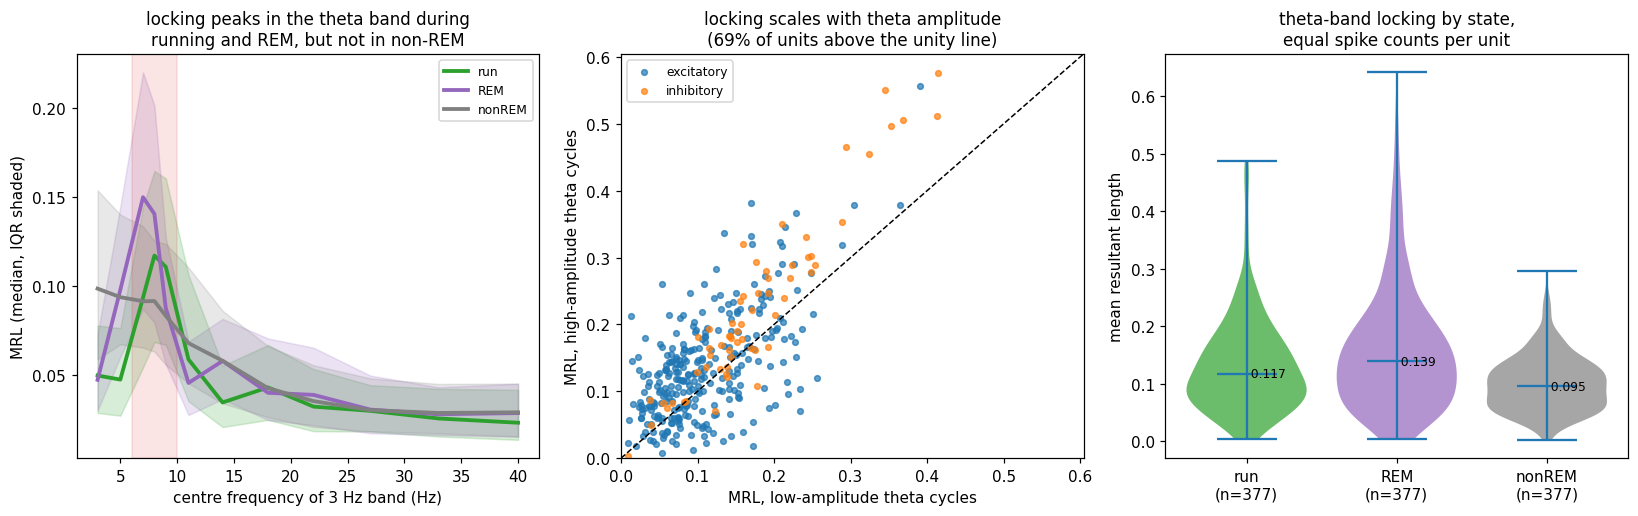

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
ax = axes[0]
freqs = results[0]["spectrum"].index.values
for state in ["run", "REM", "nonREM"]:
    pooled = [r["spectrum"][[c for c in r["spectrum"].columns if c[0] == state]].values
              for r in results]
    pooled = np.concatenate([p for p in pooled if p.size], axis=1)
    med = np.nanmedian(pooled, axis=1)
    q1, q3 = np.nanpercentile(pooled, [25, 75], axis=1)
    ax.plot(freqs, med, color=STATE_COLOR[state], lw=2.5, label=state)
    ax.fill_between(freqs, q1, q3, color=STATE_COLOR[state], alpha=0.18)
ax.axvspan(*THETA_BAND, color="C3", alpha=0.12)
ax.set_xlabel("centre frequency of 3 Hz band (Hz)")
ax.set_ylabel("MRL (median, IQR shaded)")
ax.set_title("locking peaks in the theta band during\nrunning and REM, "
             "but not in non-REM")
ax.legend(fontsize=8)

ax = axes[1]
amp = pd.concat([r["amp_split"] for r in results])
amp = amp[(amp.n_high >= MIN_SPIKES) & (amp.n_low >= MIN_SPIKES)]
for ct, sub in amp.groupby("cell_type"):
    ax.scatter(sub.mrl_low, sub.mrl_high, s=14, alpha=0.7, color=CT_COLOR[ct],
               label=ct)
lim = [0, max(amp.mrl_high.max(), amp.mrl_low.max()) * 1.05]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("MRL, low-amplitude theta cycles")
ax.set_ylabel("MRL, high-amplitude theta cycles")
ax.set_title(f"locking scales with theta amplitude\n"
             f"({100 * (amp.mrl_high > amp.mrl_low).mean():.0f}% of units above "
             "the unity line)")
ax.legend(fontsize=8)

ax = axes[2]
sub = df[(df.n_spikes >= MIN_SPIKES) & (df.n_matched >= MIN_SPIKES)]
data = [sub[sub.state == s].mrl_matched.values for s in order]
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for pc, s in zip(parts["bodies"], order):
    pc.set_facecolor(STATE_COLOR[s])
    pc.set_alpha(0.7)
for i, d_ in enumerate(data):
    ax.text(i + 1, np.median(d_), f" {np.median(d_):.3f}", fontsize=8, va="center")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f"{s}\n(n={len(d_)})" for s, d_ in zip(order, data)])
ax.set_ylabel("mean resultant length")
ax.set_title("theta-band locking by state,\nequal spike counts per unit")
plt.tight_layout()
plt.savefig("fig07_frequency_specificity.png")

## Replication across sessions and animals

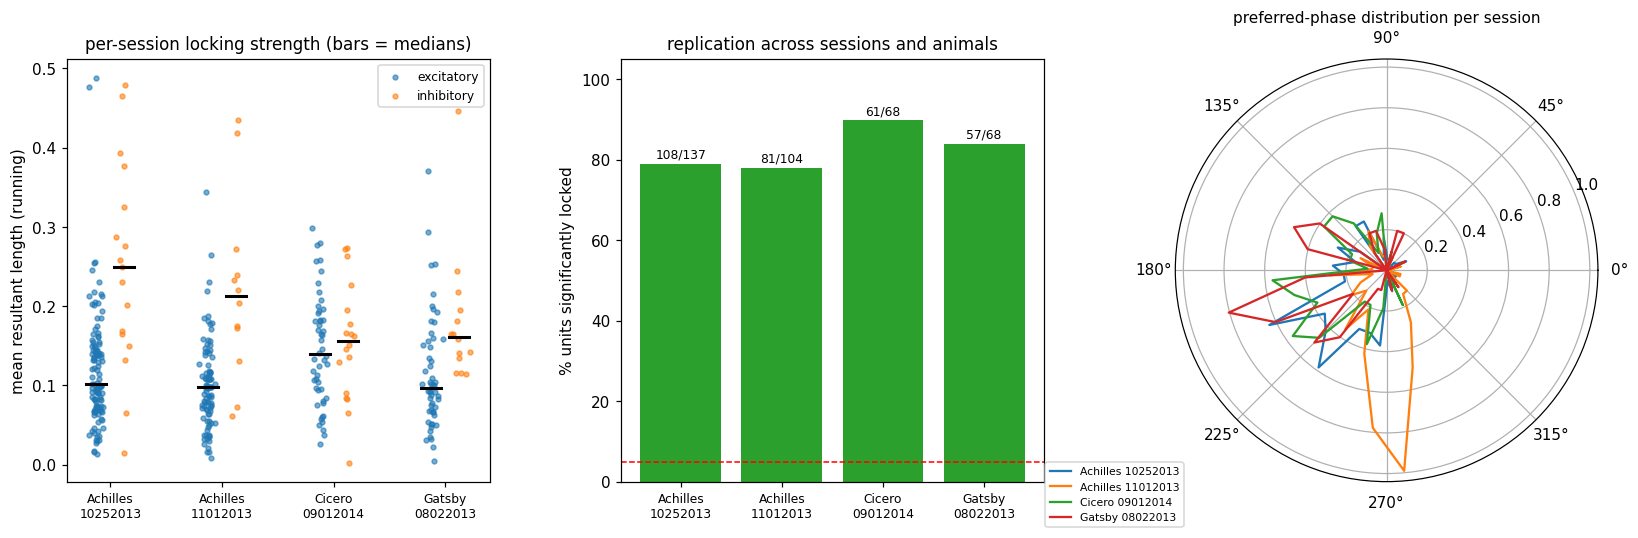

In [17]:
sessions = sorted(run.session.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
ax = axes[0]
for i, s in enumerate(sessions):
    for j, ct in enumerate(["excitatory", "inhibitory"]):
        v = run[(run.session == s) & (run.cell_type == ct)].mrl.values
        if not len(v):
            continue
        x = i + (j - 0.5) * 0.25
        ax.scatter(x + np.random.default_rng(i).normal(0, 0.03, len(v)), v, s=10,
                   alpha=0.6, color=CT_COLOR[ct], label=ct if i == 0 else None)
        ax.plot([x - 0.09, x + 0.09], [np.median(v)] * 2, color="k", lw=2)
labels = [s.split("_")[0] + "\n" + s.split("-")[-1] for s in sessions]
ax.set_xticks(range(len(sessions)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean resultant length (running)")
ax.set_title("per-session locking strength (bars = medians)")
ax.legend(fontsize=8)

ax = axes[1]
fr = [100 * (run[run.session == s].shuffle_p < 0.05).mean() for s in sessions]
ax.bar(range(len(sessions)), fr, color="C2")
for i, s in enumerate(sessions):
    n = run[run.session == s]
    ax.text(i, fr[i] + 1.5, f"{int((n.shuffle_p < 0.05).sum())}/{len(n)}",
            ha="center", fontsize=8)
ax.set_xticks(range(len(sessions)))
ax.set_xticklabels(labels, fontsize=8)
ax.axhline(5, color="r", ls="--", lw=1)
ax.set_ylim(0, 105)
ax.set_ylabel("% units significantly locked")
ax.set_title("replication across sessions and animals")

axes[2].remove()
axp = plt.subplot(1, 3, 3, projection="polar")
for s in sessions:
    cnt, _ = np.histogram(run[(run.session == s) & (run.shuffle_p < 0.05)].pref_phase,
                          bins=BINS, density=True)
    axp.plot(np.append(CENTERS, CENTERS[0]), np.append(cnt, cnt[0]), lw=1.5,
             label=f"{s.split('_')[0]} {s.split('-')[-1]}")
axp.set_title("preferred-phase distribution per session", fontsize=10, pad=24)
axp.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.32, -0.12))
plt.tight_layout()
plt.savefig("fig08_across_sessions.png", bbox_inches="tight")

## Numbers

In [18]:
print(f"sessions: {df.session.nunique()}, units analysed during running: {len(run)}")
print(f"significantly locked (circular-shift, p<0.05): "
      f"{(run.shuffle_p < 0.05).sum()} ({100 * (run.shuffle_p < 0.05).mean():.0f}%)")
bonf = 0.05 / len(run)
print(f"Rayleigh p < {bonf:.2e} (Bonferroni): {(run.rayleigh_p < bonf).sum()} units")
for ct, sub in run.groupby("cell_type"):
    mean_pref = np.mod(np.angle(np.exp(1j * sub.pref_phase).mean()), 2 * np.pi)
    print(f"  {ct}: n={len(sub)}, median MRL={sub.mrl.median():.3f}, "
          f"locked={100 * (sub.shuffle_p < 0.05).mean():.0f}%, "
          f"mean preferred phase={np.degrees(mean_pref):.0f}°")

u_stat, p_val = mannwhitneyu(run[run.cell_type == "excitatory"].mrl,
                             run[run.cell_type == "inhibitory"].mrl)
print(f"excitatory vs inhibitory MRL: Mann-Whitney U={u_stat:.0f}, p={p_val:.2e}")

w_stat, p_amp = wilcoxon(amp.mrl_high, amp.mrl_low)
print(f"MRL on high- vs low-amplitude theta cycles: n={len(amp)}, "
      f"{100 * (amp.mrl_high > amp.mrl_low).mean():.0f}% higher, "
      f"Wilcoxon p={p_amp:.2e}")

print(f"run vs REM preferred phase (units locked in both): n={len(piv)}, "
      f"concentration={rho:.2f}, median offset={np.degrees(np.median(d)):+.0f}°, "
      f"Rayleigh z={len(piv) * rho ** 2:.1f}")
print("\nspike-count-matched median MRL by state:")
print(df[df.n_matched >= MIN_SPIKES].groupby("state").mrl_matched.median()
      .round(3).to_string())

sessions: 4, units analysed during running: 377
significantly locked (circular-shift, p<0.05): 307 (81%)
Rayleigh p < 1.33e-04 (Bonferroni): 265 units
  excitatory: n=316, median MRL=0.102, locked=78%, mean preferred phase=217°
  inhibitory: n=61, median MRL=0.173, locked=97%, mean preferred phase=156°
excitatory vs inhibitory MRL: Mann-Whitney U=4699, p=2.33e-10
MRL on high- vs low-amplitude theta cycles: n=355, 69% higher, Wilcoxon p=2.09e-17
run vs REM preferred phase (units locked in both): n=238, concentration=0.32, median offset=+17°, Rayleigh z=24.1

spike-count-matched median MRL by state:
state
REM       0.139
nonREM    0.095
run       0.117


## What the analysis shows

Hippocampal CA1 neurons are entrained by the theta rhythm. During running,
307 of 377 units (81%) fire at a significantly non-uniform theta phase by the
circular-shift test, and 265 also survive a Bonferroni-corrected Rayleigh
test. Putative interneurons are entrained substantially more strongly than
putative pyramidal cells (median MRL 0.173 against 0.102) and are locked almost without
exception (97% against 78% of units). That ordering is the expected one:
perisomatic interneurons are driven directly by the rhythmic inhibitory and
septal input that generates the field oscillation, while pyramidal cells fire
sparsely and are additionally modulated by their place fields.

Three controls argue that this is genuine oscillatory entrainment. Locking
strength peaks in the theta band when the analysis is repeated across
frequency bands; 69% of units lock more strongly on high-amplitude than on
low-amplitude theta cycles; and locking appears in both states that have a
theta peak in the LFP power spectrum. Units locked in both running and REM
tend to keep their preferred phase across the two states, though not tightly
(circular concentration of the phase difference 0.32 over 238 units, median
offset +17°, Rayleigh z = 24).

Non-REM sleep deserves a caveat rather than a clean negative. There is no
theta peak in the non-REM power spectrum, yet band-passing the signal at
6-10 Hz still yields a phase, and units show apparent locking to it. The
population map makes the reason visible: in non-REM every unit prefers nearly
the same phase, which is the signature of synchronous population bursts
(sharp-wave ripples) producing a transient that the band-pass filter turns
into a consistent phase estimate. In running and REM the preferred phases are
spread around the cycle, as expected when individual cells are entrained to an
ongoing oscillation rather than dragged along by a shared event. Once spike
counts are matched across states, the median MRL is 0.139 in REM, 0.117 during
running, and 0.095 in non-REM.

Two limits are worth stating. The absolute preferred phase depends on where
the recording channel sits relative to the CA1 layers, because theta reverses
phase across the pyramidal layer and the hippocampal fissure; the channel here
was chosen for maximum theta power, so the numerical phase values are not
directly comparable across sessions and only the within-session structure
should be read. And phase locking is measured here without regard to position
on the track, so it is averaged over any phase precession within place fields,
which reduces the measured locking of pyramidal cells.